<a href="https://colab.research.google.com/github/AmanuelDaget/YOLOv12-Object-Recognition-from-Remote-Sensing-images/blob/main/YOLOv12_Object_Recognition_from_Remote_Sensing_images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 562.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 6.3 MB/s eta 0:00:00


In [2]:
import os, shutil, random, cv2, yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm import tqdm
from google.colab import drive
from ultralytics import YOLO

random.seed(42);
np.random.seed(42)
print('Libraries ready')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Libraries ready


In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
BASE = '/content/drive/MyDrive/Colab Notebooks/Computer Vision and Image Processing/Object-detection-using-YOLOv12'

RAW = {
    'train_img': f'{BASE}/training/images',
    'train_lbl': f'{BASE}/training/labels',
    'test_img' : f'{BASE}/test/images',
    'test_lbl' : f'{BASE}/test/labels',
}

WORK = '/content/simd_yolo'  # fast local Colab storage
for sub in ['images/train','images/val','images/test',
             'labels/train','labels/val','labels/test']:
    os.makedirs(f'{WORK}/{sub}', exist_ok=True)

print('Paths ready')

Paths ready


/tmp/ipykernel_522/1447855717.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=names, y=vals, palette='viridis')


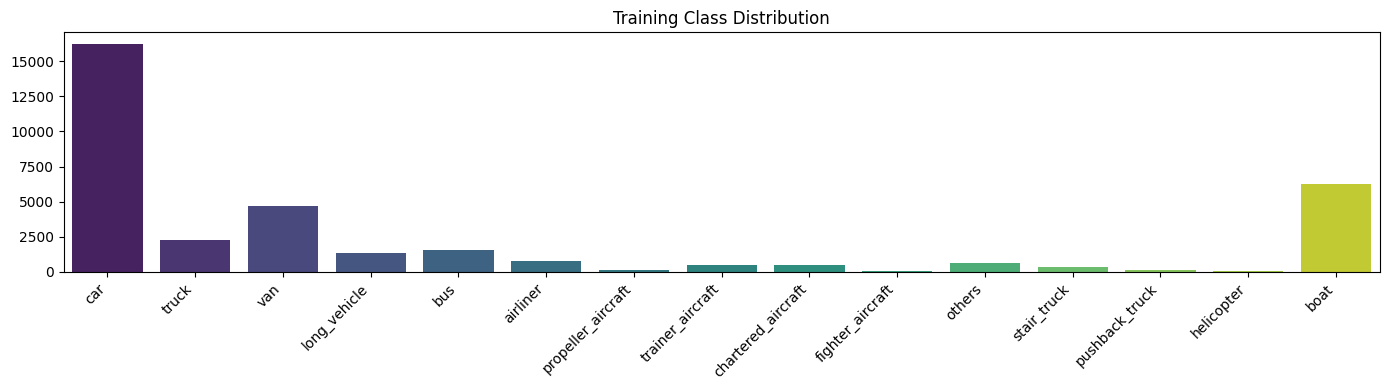

Total training boxes: 35577


In [7]:
CLASS_NAMES = ["car","truck","van","long_vehicle","bus","airliner","propeller_aircraft",
           "trainer_aircraft","chartered_aircraft","fighter_aircraft",
           "others","stair_truck","pushback_truck","helicopter","boat"]

def count_classes(lbl_dir):
    c = Counter()
    for f in Path(lbl_dir).glob('*.txt'):
        for line in f.read_text().splitlines():
            c[int(line.split()[0])] += 1
    return c

counts = count_classes(RAW['train_lbl'])
ids    = sorted(counts); vals = [counts[i] for i in ids]
names  = [CLASS_NAMES[i] if i < len(CLASS_NAMES) else str(i) for i in ids]

plt.figure(figsize=(14,4))
sns.barplot(x=names, y=vals, palette='viridis')
plt.xticks(rotation=45, ha='right'); plt.title('Training Class Distribution')
plt.tight_layout(); plt.show()
print('Total training boxes:', sum(vals))

In [8]:
# ── CLAHE ─────────────────────────────────────────────────────────────────
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def apply_clahe(img_bgr):
    """Enhance local contrast via CLAHE on L channel (LAB space)."""
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)


# ── Tiling ────────────────────────────────────────────────────────────────
TILE, OVERLAP = 512, 64
STRIDE = TILE - OVERLAP

def yolo_to_abs(parts, W, H):
    c, cx, cy, bw, bh = parts
    return [c, (cx-bw/2)*W, (cy-bh/2)*H, (cx+bw/2)*W, (cy+bh/2)*H]

def tile_one(img_path, lbl_path, out_img, out_lbl, stem):
    """
    CLAHE → slice image into TILE×TILE crops with OVERLAP.
    Each tile keeps only labels whose centre falls inside it (box clipped & re-normalised).
    Background-only tiles are discarded. Returns tile count.
    """
    img = cv2.imread(img_path)
    if img is None: return 0
    img = apply_clahe(img)
    H, W = img.shape[:2]

    abs_labels = []
    if os.path.exists(lbl_path):
        for line in Path(lbl_path).read_text().splitlines():
            abs_labels.append(yolo_to_abs(list(map(float, line.split())), W, H))

    count = 0
    for y0 in range(0, H, STRIDE):
        for x0 in range(0, W, STRIDE):
            x1, y1 = min(x0 + TILE, W), min(y0 + TILE, H)
            tile   = img[y0:y1, x0:x1]
            th, tw = tile.shape[:2]

            tile_lbls = []
            for c, bx1, by1, bx2, by2 in abs_labels:
                bcx, bcy = (bx1+bx2)/2, (by1+by2)/2
                if not (x0 <= bcx < x1 and y0 <= bcy < y1):  # centre must be inside tile
                    continue
                nx1 = max(bx1-x0, 0);  ny1 = max(by1-y0, 0)
                nx2 = min(bx2-x0, tw); ny2 = min(by2-y0, th)
                ncx = ((nx1+nx2)/2)/tw; ncy = ((ny1+ny2)/2)/th
                nbw = (nx2-nx1)/tw;     nbh = (ny2-ny1)/th
                if nbw > 0.005 and nbh > 0.005:
                    tile_lbls.append(f'{int(c)} {ncx:.6f} {ncy:.6f} {nbw:.6f} {nbh:.6f}')

            if not tile_lbls:
                continue

            tid = f'{stem}_{count:03d}'
            cv2.imwrite(f'{out_img}/{tid}.jpg', tile)
            Path(f'{out_lbl}/{tid}.txt').write_text('\n'.join(tile_lbls))
            count += 1
    return count


# ── Rare-class oversampling ───────────────────────────────────────────────
median_cnt = np.median([counts[i] for i in counts])
RARE_CLS   = {i for i, v in counts.items() if v < median_cnt * 0.3}
print('Rare class IDs (will be oversampled):', RARE_CLS)

def has_rare(lbl_path):
    return any(int(l.split()[0]) in RARE_CLS
               for l in Path(lbl_path).read_text().splitlines())


# ── Process function ──────────────────────────────────────────────────────
def process_split(img_list, lbl_dir, out_img, out_lbl, oversample=False):
    total = 0
    for p in tqdm(img_list, desc=Path(out_img).parts[-2]):
        stem = p.stem
        lbl  = f'{lbl_dir}/{stem}.txt'
        total += tile_one(str(p), lbl, out_img, out_lbl, stem)
        # tile rare-class images a second time with '_os' suffix
        if oversample and os.path.exists(lbl) and has_rare(lbl):
            tile_one(str(p), lbl, out_img, out_lbl, stem + '_os')
    return total

Rare class IDs (will be oversampled): {9, 12, 13, 6}


In [ ]:
all_train = sorted(Path(RAW['train_img']).glob('*.[Jj][Pp][Gg]'))
random.shuffle(all_train)
val_imgs, train_imgs = all_train[:800], all_train[800:]
print(f'Train source: {len(train_imgs)} | Val source: {len(val_imgs)}')

n_tr  = process_split(train_imgs, RAW['train_lbl'],
                      f'{WORK}/images/train', f'{WORK}/labels/train', oversample=True)
n_val = process_split(val_imgs,   RAW['train_lbl'],
                      f'{WORK}/images/val',   f'{WORK}/labels/val')
n_te  = process_split(sorted(Path(RAW['test_img']).glob('*.[Jj][Pp][Gg]')),
                      RAW['test_lbl'],
                      f'{WORK}/images/test', f'{WORK}/labels/test')

print(f'Tiles — Train: {n_tr} | Val: {n_val} | Test: {n_te}')

Train source: 3200 | Val source: 800


images:   0%|          | 1/1000 [00:01<20:14,  1.22s/it]

In [ ]:
def draw_boxes(img_bgr, lbl_path):
    img = img_bgr.copy(); H, W = img.shape[:2]
    for line in Path(lbl_path).read_text().splitlines():
        c, cx, cy, bw, bh = map(float, line.split())
        x1,y1 = int((cx-bw/2)*W), int((cy-bh/2)*H)
        x2,y2 = int((cx+bw/2)*W), int((cy+bh/2)*H)
        cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)
        name = CLASS_NAMES[int(c)] if int(c)<len(CLASS_NAMES) else str(int(c))
        cv2.putText(img,name,(x1,max(y1-5,0)),cv2.FONT_HERSHEY_SIMPLEX,0.4,(0,255,0),1)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

samples = random.sample(sorted(Path(f'{WORK}/images/train').glob('*.jpg')), 6)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, p in zip(axes.flatten(), samples):
    lbl = str(p).replace('/images/', '/labels/').replace('.jpg', '.txt')
    ax.imshow(draw_boxes(cv2.imread(str(p)), lbl))
    ax.set_title(p.name, fontsize=8); ax.axis('off')
plt.suptitle('Preprocessed Training Tiles (CLAHE + Tiled)', fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
cfg = {'path': WORK, 'train': 'images/train', 'val': 'images/val',
       'test': 'images/test', 'nc': len(CLASS_NAMES), 'names': CLASS_NAMES}
YAML = f'{WORK}/simd.yaml'
with open(YAML, 'w') as f: yaml.dump(cfg, f, default_flow_style=False)
print(open(YAML).read())

In [ ]:
model = YOLO('yolo12s.pt')   # auto-downloads

results = model.train(
    data    = YAML,
    epochs  = 50,
    imgsz   = 512,           # matches tile size
    batch   = 16,
    lr0     = 0.01, lrf = 0.01,
    warmup_epochs = 3,
    cos_lr  = True,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=10, flipud=0.5, fliplr=0.5, mosaic=1.0,
    patience = 15,
    save_period = 10,
    project = f'{WORK}/runs',
    name    = 'simd_yolo12s',
    exist_ok = True
)